# Desafio Digital Grid — Ricardo M. D. C. Junior

Solução das questões Q0 a Q5. O resumo do que fiz (e do que deixei de fora) está no
`SOLUCAO.md`. Mês de referência: **2026-07-01**.

In [1]:
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 4)

---
## Q0 — Contrato de dados

Explorei as duas bases antes de escrever a função. O que encontrei:

**Consumo (5.074 linhas):**
- A mesma UC aparece com o ID formatado (`11.140.345.018-70`) e também só com
  dígitos (`1114034501870`). Conferi: os meses não se sobrepõem, ou seja, é a mesma
  série partida em duas. Sem juntar, a UC contaria duas vezes no rateio.
- 10 UCs têm sufixo `-CANCEL` no ID. Todas estão com consumo zero há meses e várias
  com saldo alto parado. O status virou uma coluna `cancelada` (vou precisar disso na Q4).
- 7 pares de linhas 100% duplicadas e mais 7 pares com a mesma UC/mês e valores um
  pouco diferentes (ex.: 24.141 vs 24.128) — parece refaturamento. Como não tem coluna
  de versão pra saber qual vale, fiquei com a média (a diferença é <1%).
- 4 consumos negativos (estorno?) e 7 valores absurdos tipo 15.070 kWh numa UC cuja
  mediana é 1.622 e o segundo maior valor é 2.415 — quase certeza de dígito extra
  (1.507 → 15.070). Usei a regra: valor > 8× a mediana da própria UC.

**Usina (49 linhas):** uma linha sem data, jul/2022 com 1 kWh (comissionamento) e um
colapso de geração em mar–jun/2024 (~24 mil vs ~300–400 mil nos vizinhos).

Decisão importante: o enunciado da Q1 diz que o rateio usa o consumo faturado **como
está**. Então negativos e outliers ficam na coluna `consumo_kwh` e a correção vai
para uma coluna separada, `consumo_modelagem` (NaN onde o valor é suspeito), que é a
que uso na Q3. A anomalia da usina fica só sinalizada (`flag_anomalia`) — a decisão
de usar ou não é da modelagem.

In [2]:
CAMINHO_CONSUMO = "consumer_unit_data.xlsx"
CAMINHO_USINA = "power_plant_data.xlsx"


def carregar_e_limpar(caminho_consumo=CAMINHO_CONSUMO, caminho_usina=CAMINHO_USINA):
    """Lê e limpa as duas bases. Devolve (consumo, usina, relatorio_de_qualidade).

    Função pura dos arquivos de entrada -> idempotente por construção.
    Garante 1 linha por UC/mês na base de consumo.
    """
    log = []

    def registrar(base, etapa, n, acao, motivo):
        log.append({"base": base, "etapa": etapa, "registros": int(n),
                    "acao": acao, "motivo": motivo})

    # ----- consumo -----
    cu = pd.read_excel(caminho_consumo)
    cu.columns = ["mes", "uc_original", "consumo_kwh", "saldo_kwh"]
    registrar("consumo", "leitura", len(cu), "entrada", "registros lidos do Excel")

    # normaliza o ID: tira -CANCEL, casa IDs sem máscara com a forma formatada
    uc = cu["uc_original"].str.strip()
    cancelada = uc.str.endswith("-CANCEL")
    uc = uc.str.replace("-CANCEL", "", regex=False)
    digitos = uc.str.replace(r"\D", "", regex=True)
    formatadas = uc[uc.str.contains(".", regex=False)]
    mapa = dict(zip(formatadas.str.replace(r"\D", "", regex=True), formatadas))
    cu["uc"] = digitos.map(lambda d: mapa.get(d, d))
    registrar("consumo", "normalizacao de ID", (cu["uc"] != uc).sum(), "corrigido",
              "IDs sem máscara unificados com o gêmeo formatado (mesmos dígitos = mesma UC)")

    ucs_canceladas = set(cu.loc[cancelada, "uc"])
    cu["cancelada"] = cu["uc"].isin(ucs_canceladas)
    registrar("consumo", "flag -CANCEL", cancelada.sum(), "corrigido",
              f"sufixo removido do ID e virou coluna booleana ({len(ucs_canceladas)} UCs)")

    antes = len(cu)
    cu = cu.drop_duplicates(subset=["mes", "uc", "consumo_kwh", "saldo_kwh"])
    registrar("consumo", "duplicata exata", antes - len(cu), "descartado",
              "mesma UC/mês/valores")

    n_conf = cu.duplicated(subset=["mes", "uc"], keep=False).sum()
    cu = (cu.groupby(["mes", "uc", "cancelada"], as_index=False)
            .agg(consumo_kwh=("consumo_kwh", "mean"), saldo_kwh=("saldo_kwh", "mean")))
    cu["consumo_kwh"] = cu["consumo_kwh"].round().astype(int)
    cu["saldo_kwh"] = cu["saldo_kwh"].round().astype(int)
    registrar("consumo", "duplicata conflitante", n_conf, "média",
              "mesma UC/mês, valores <1% diferentes; sem versão da fatura, média")

    cu["consumo_modelagem"] = cu["consumo_kwh"].astype(float)
    neg = cu["consumo_kwh"] < 0
    cu.loc[neg, "consumo_modelagem"] = np.nan
    registrar("consumo", "consumo negativo", neg.sum(), "NaN p/ modelagem",
              "faturado fica como está (regra da Q1); p/ modelo não é consumo físico")

    mediana_uc = cu.groupby("uc")["consumo_kwh"].transform("median")
    outlier = (cu["consumo_kwh"] > 8 * mediana_uc) & (mediana_uc > 100)
    cu.loc[outlier, "consumo_modelagem"] = np.nan
    registrar("consumo", "outlier de digitação", outlier.sum(), "NaN p/ modelagem",
              "> 8x a mediana da própria UC (todos ~10x o 2º maior valor)")

    cu = cu.sort_values(["uc", "mes"]).reset_index(drop=True)

    # ----- usina -----
    pp = pd.read_excel(caminho_usina)
    pp.columns = ["mes", "usina", "geracao_kwh"]
    registrar("usina", "leitura", len(pp), "entrada", "registros lidos do Excel")

    sem_data = pp["mes"].isna()
    pp = pp[~sem_data]
    registrar("usina", "sem data", sem_data.sum(), "descartado", "linha NaT com geração 0")

    espuria = pp["geracao_kwh"] <= 1
    pp = pp[~espuria]
    registrar("usina", "comissionamento", espuria.sum(), "descartado",
              "jul/2022 com 1 kWh não é operação")

    pp["flag_anomalia"] = pp["mes"].between("2024-03-01", "2024-06-01")
    registrar("usina", "colapso mar-jun/24", pp["flag_anomalia"].sum(), "sinalizado",
              "queda de ~93% por 4 meses; mantido, decisão fica p/ Q3b")

    pp = pp.sort_values("mes").reset_index(drop=True)
    return cu, pp, pd.DataFrame(log)


consumo, usina, relatorio = carregar_e_limpar()
relatorio

,base,etapa,registros,acao,motivo
0,consumo,leitura,5074,entrada,registros lidos do Excel
1,consumo,normalizacao de ID,107,corrigido,IDs sem máscara unificados com o gêmeo formata...
2,consumo,flag -CANCEL,356,corrigido,sufixo removido do ID e virou coluna booleana ...
3,consumo,duplicata exata,7,descartado,mesma UC/mês/valores
4,consumo,duplicata conflitante,14,média,"mesma UC/mês, valores <1% diferentes; sem vers..."
5,consumo,consumo negativo,4,NaN p/ modelagem,faturado fica como está (regra da Q1); p/ mode...
6,consumo,outlier de digitação,7,NaN p/ modelagem,> 8x a mediana da própria UC (todos ~10x o 2º ...
7,usina,leitura,49,entrada,registros lidos do Excel
8,usina,sem data,1,descartado,linha NaT com geração 0
9,usina,comissionamento,1,descartado,jul/2022 com 1 kWh não é operação


In [3]:
# idempotência (rodar 2x = mesmo resultado) e estrutura (1 linha por UC/mês)
c2, u2, r2 = carregar_e_limpar()
assert consumo.equals(c2) and usina.equals(u2) and relatorio.equals(r2)
assert not consumo.duplicated(subset=["mes", "uc"]).any()

print(f"consumo: {len(consumo)} linhas, {consumo['uc'].nunique()} UCs "
      f"({consumo.loc[consumo['cancelada'], 'uc'].nunique()} canceladas), "
      f"{consumo['mes'].min():%Y-%m} a {consumo['mes'].max():%Y-%m}")
print(f"usina: {len(usina)} meses, {usina['mes'].min():%Y-%m} a {usina['mes'].max():%Y-%m}")

consumo: 5060 linhas, 196 UCs (10 canceladas), 2023-07 a 2026-06
usina: 47 meses, 2022-08 a 2026-06


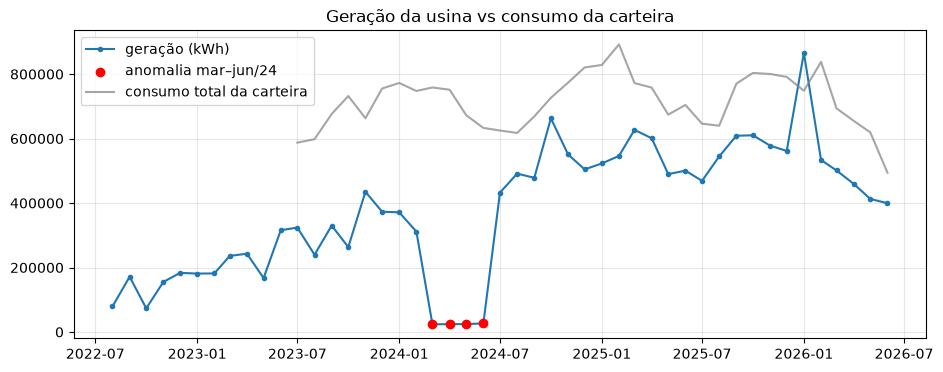

In [4]:
fig, ax = plt.subplots()
ax.plot(usina["mes"], usina["geracao_kwh"], marker="o", ms=3, label="geração (kWh)")
anom = usina[usina["flag_anomalia"]]
ax.scatter(anom["mes"], anom["geracao_kwh"], color="red", zorder=5, label="anomalia mar–jun/24")
tot = consumo.groupby("mes")["consumo_kwh"].sum()
ax.plot(tot.index, tot.values, color="gray", alpha=0.7, label="consumo total da carteira")
ax.set_title("Geração da usina vs consumo da carteira")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

O gráfico já entrega três coisas que vão importar adiante: o degrau de capacidade da
usina em jul/2024, o colapso de mar–jun/2024, e a geração de 2026 **caindo mês a mês**
enquanto o consumo da carteira segue estável.